## Imports and Functions

In [13]:
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

from pathlib import Path

from CSE583_humanSayMonkeyDo.load_config import get_data_paths

from CSE583_humanSayMonkeyDo.data_loading import(
    get_nwbs,
    get_neural_data,
    get_trial_times,
    get_kinematics,
)

from CSE583_humanSayMonkeyDo.visualization import(
    plot_lda_results,
    plot_firing_rate_heatmap,
)

from CSE583_humanSayMonkeyDo.data_formatting import(
    get_windowed_pos_chunk,
    get_chunk_spikes_binned_windowed,
)

from CSE583_humanSayMonkeyDo.analysis import(
    get_movement_onset_times,
    train_lda_classifier,
)

# Load Monkey Data

In [14]:
#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
m_nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
m_nwbfile

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


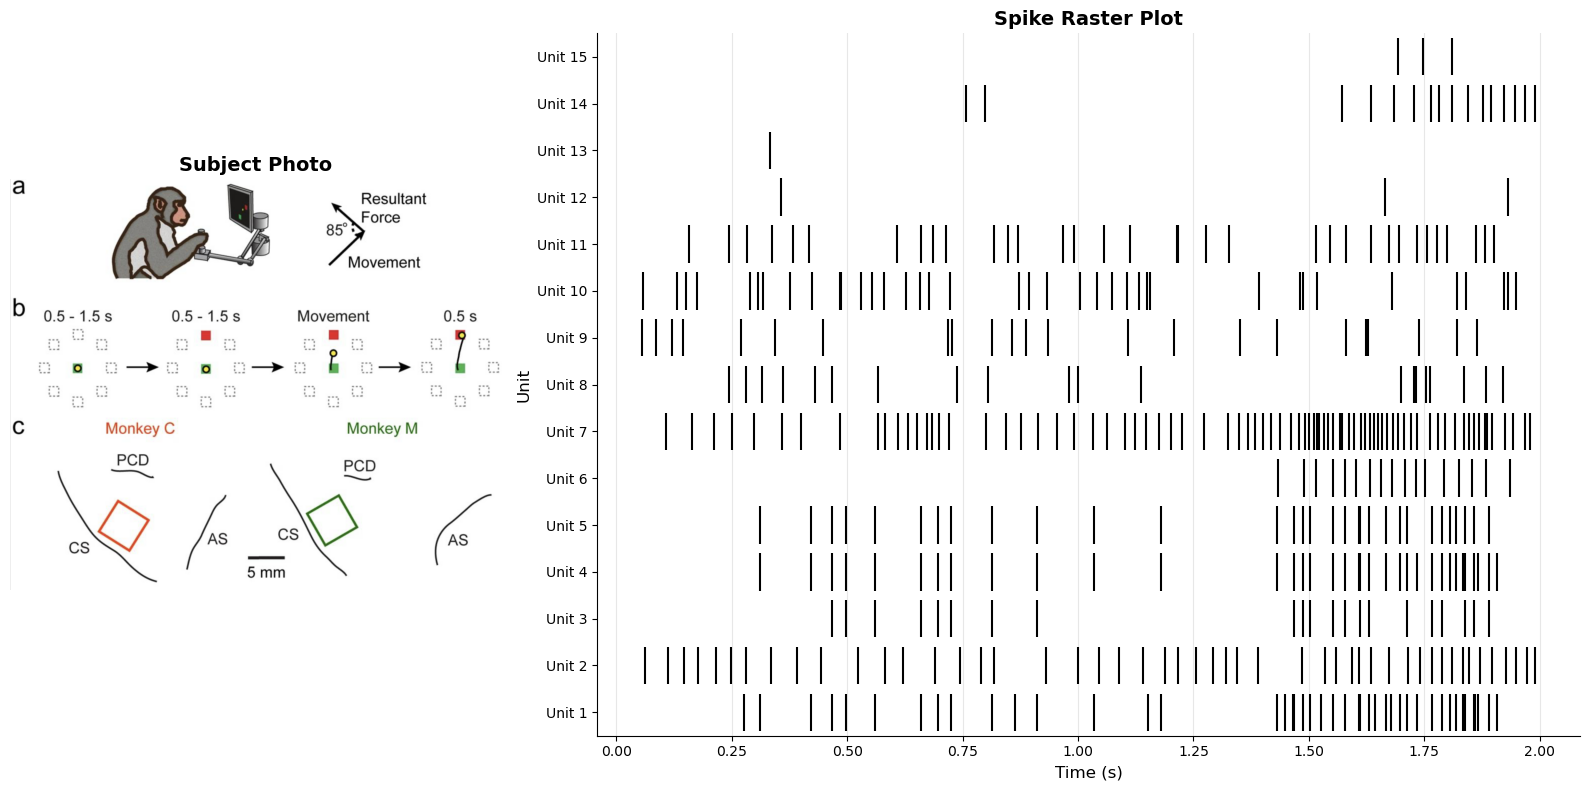

In [15]:
data_paths = get_data_paths()

# Load your photo
photo_path = Path(data_paths['root'].parent, 'doc/ref_pic/Monkey_data.png')  # Replace with your image path
photo = Image.open(photo_path)

# Load or create your spike data
# Assuming spike_times is a list of arrays, where each array contains spike times for one unit
# Example format: spike_times = [array([0.1, 0.3, 0.5, ...]), array([0.2, 0.4, ...]), ...]
# Replace this with your actual data loading
n_units = 15
trial_duration = 2.0  # seconds
spike_times = m_nwbfile.units['spike_times'][:]

for idx, unit in enumerate(spike_times):
    unit = unit[unit<trial_duration]
    spike_times[idx] = unit

#np.sort(np.random.uniform(0, trial_duration, np.random.randint(20, 80))) 
#               for _ in range(n_units)]



# Create figure with custom layout
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, width_ratios=[1, 2], figure=fig)

# Left panel: Photo
ax_photo = fig.add_subplot(gs[0])
ax_photo.imshow(photo)
ax_photo.axis('off')
ax_photo.set_title('Subject Photo', fontsize=14, fontweight='bold')

# Right panel: Spike raster
ax_raster = fig.add_subplot(gs[1])

# Plot spike raster
for unit_idx, spikes in enumerate(spike_times):
    ax_raster.eventplot(spikes, lineoffsets=unit_idx, linelengths=0.8, 
                        linewidths=1.5, colors='black')

ax_raster.set_xlabel('Time (s)', fontsize=12)
ax_raster.set_ylabel('Unit', fontsize=12)
ax_raster.set_title('Spike Raster Plot', fontsize=14, fontweight='bold')
ax_raster.set_ylim(-0.5, n_units - 0.5)
ax_raster.set_yticks(np.arange(n_units))
ax_raster.set_yticklabels([f'Unit {i+1}' for i in range(n_units)])
ax_raster.grid(True, alpha=0.3, axis='x')
ax_raster.spines['top'].set_visible(False)
ax_raster.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Get Trial Times

Index(['trial_start', 'go', 'trial_end'], dtype='object')


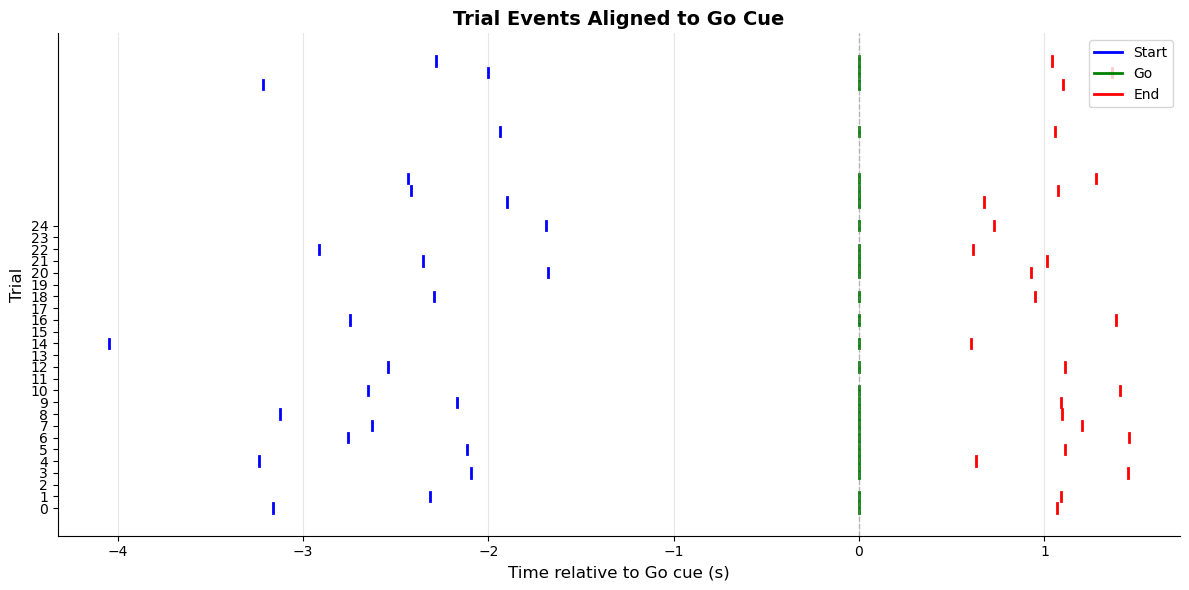

In [16]:

nwbfile = m_nwbfile
kinematics, timestamps, metadata = get_kinematics(nwbfile)
trial_times, metadata = get_trial_times(nwbfile)


trial_times, metadata = get_trial_times(nwbfile)

# Select 5 trials
n_trials = 25
trials_to_plot = trial_times.head(n_trials)
print(trial_times.keys())
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# For each trial, align to go time (go = 0)
for idx, trial in trials_to_plot.iterrows():
    trial_id = idx
    go_time = trial['go']
    
    # Calculate relative times (centered at go)
    start_rel = trial['trial_start'] - go_time
    go_rel = 0  # go time is always 0 in aligned coordinates
    end_rel = trial['trial_end'] - go_time
    
    # Plot vertical lines
    ax.plot([start_rel, start_rel], [idx - 0.4, idx + 0.4], 'b-', linewidth=2, label='Start' if idx == 0 else '')
    ax.plot([go_rel, go_rel], [idx - 0.4, idx + 0.4], 'g-', linewidth=2, label='Go' if idx == 0 else '')
    ax.plot([end_rel, end_rel], [idx - 0.4, idx + 0.4], 'r-', linewidth=2, label='End' if idx == 0 else '')

# Formatting
ax.set_xlabel('Time relative to Go cue (s)', fontsize=12)
ax.set_ylabel('Trial', fontsize=12)
ax.set_title('Trial Events Aligned to Go Cue', fontsize=14, fontweight='bold')
ax.set_yticks(range(n_trials))
#ax.set_yticklabels([f'Trial {int(trial["id"])}' for _, trial in trials_to_plot.iterrows()])
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



# Visualize Kinematics

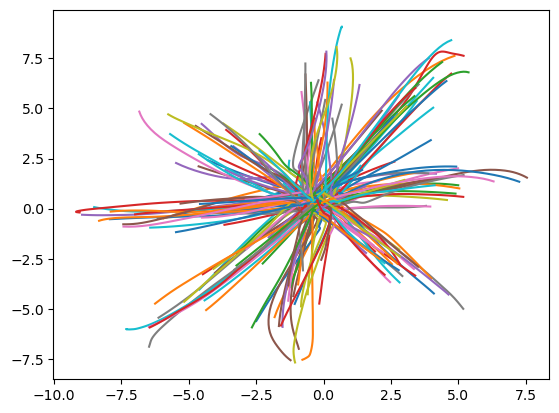

In [17]:

#cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = trial_times['go']
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(kinematics, timestamps, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])


# Load and Visualize Trial Average Neural Data

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

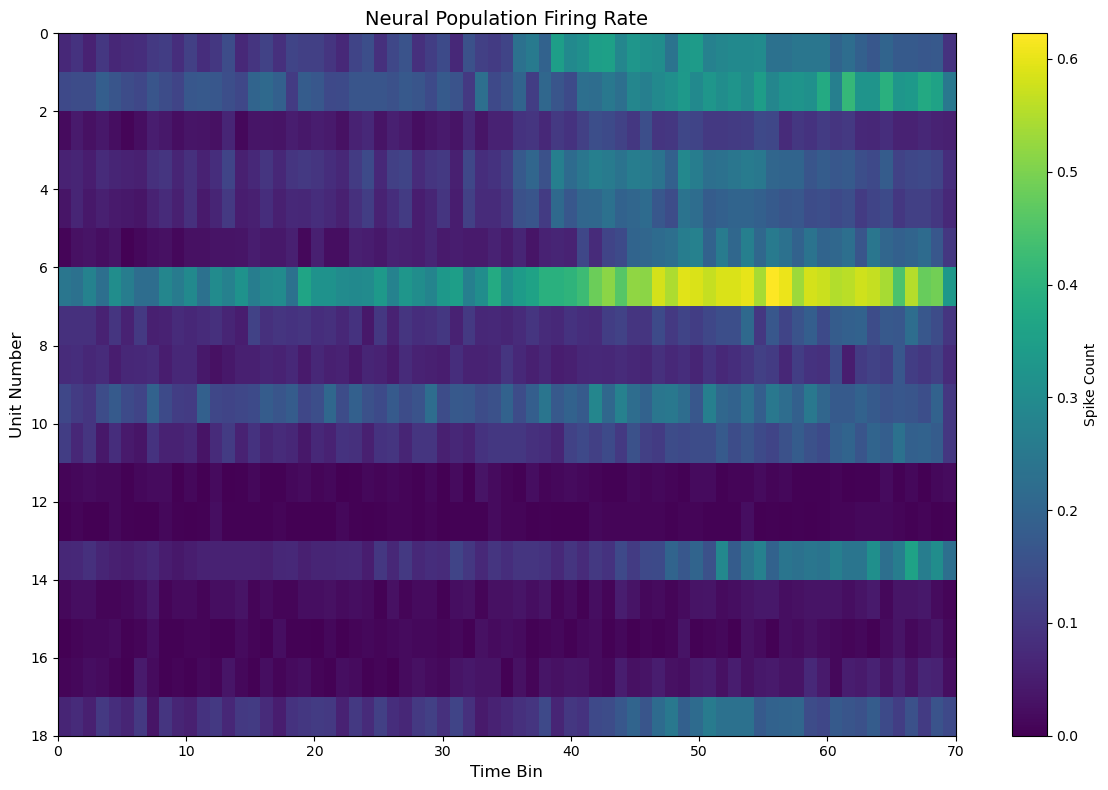

In [18]:

neural_data, metadata = get_neural_data(nwbfile, go_cue_times, window)
avg_spike_rates = np.mean(neural_data,axis=0)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

(220, 18, 21)
Data shape: (440, 378)
Labels shape: (440,)
Class distribution: 0=220, 1=220

=== LDA Classification Results ===
Training Accuracy: 0.996
Test Accuracy: 0.670
Cross-validation Accuracy: 0.595 (+/- 0.076)

CV Scores: [0.47727273 0.56818182 0.57954545 0.69318182 0.65909091]

=== Test Set Confusion Matrix ===
[[60 28]
 [30 58]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.67      0.68      0.67        88
     Class 1       0.67      0.66      0.67        88

    accuracy                           0.67       176
   macro avg       0.67      0.67      0.67       176
weighted avg       0.67      0.67      0.67       176



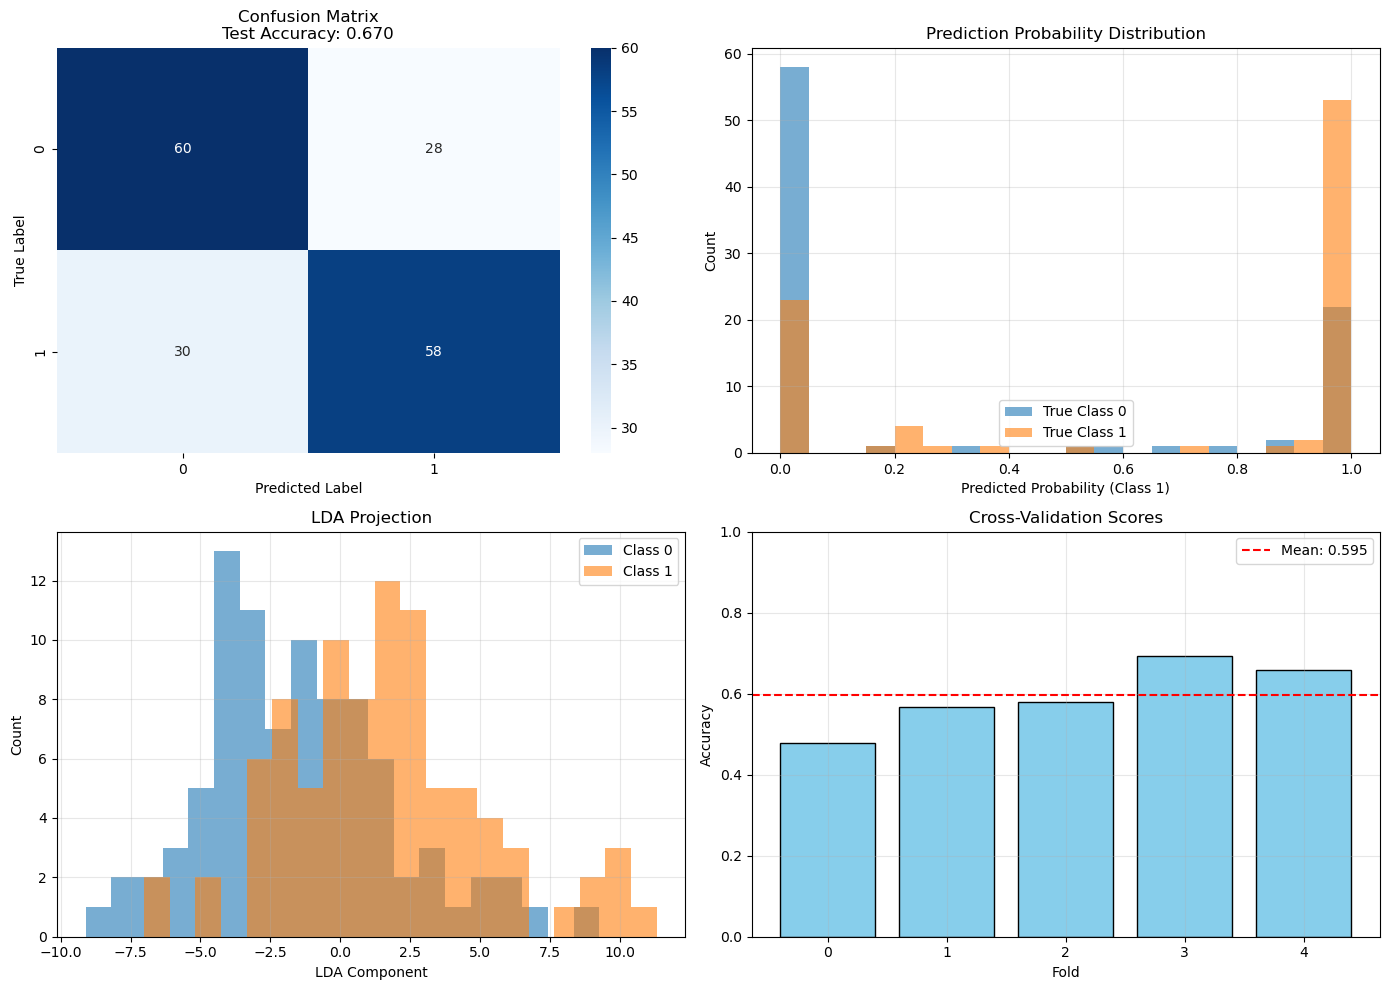

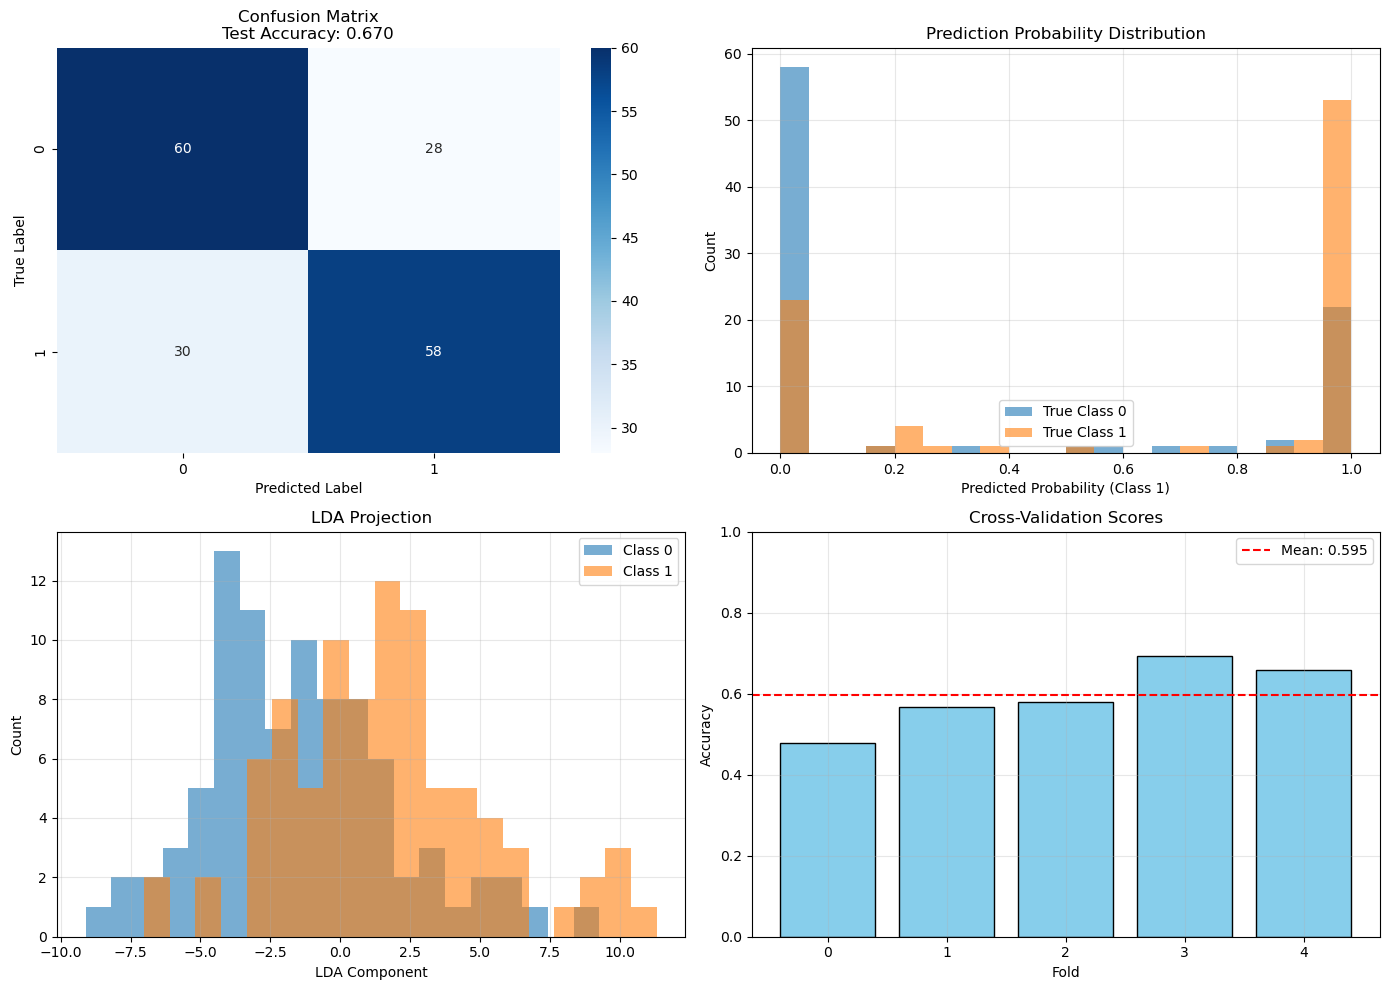

In [19]:
cursor_vel, timestamps, metadata = get_kinematics(m_nwbfile, kin_type="Velocity")

movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    timestamps,
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

valid_trials = ~np.isnan(movement_times)


window = [0.0, 0.2]
movement_spike_data, metadata = get_neural_data(nwbfile, movement_times[valid_trials], window, bin_size=0.01)

window = [0.2, 0.0]
stationary_spike_data, metadata = get_neural_data(nwbfile, go_cue_times[valid_trials], window, bin_size=0.01)




data = movement_spike_data
move_category = np.ones(movement_spike_data.shape[0], dtype=int)  # All ones for movement

print(data.shape)
data = np.concatenate([data, stationary_spike_data], axis=0)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data.shape[0], dtype=int)])  # All zeros for stationary


lda, results = train_lda_classifier(data, move_category)

# Visualize
plot_lda_results(results)
